In [17]:
import pandas as pd

In [36]:
python_res = pd.read_csv("./python_res.csv")
rust_res = pd.read_csv("./res.csv")

In [37]:
# Filter only task 1 (params start with "t1-...")
python_res = python_res[python_res["params"].str.startswith("t1-")]

# For rust it is param that contains "task1"
rust_res = rust_res[rust_res["params"].str.contains("task1")]

# Filter only size 300K
python_res = python_res[python_res["size"] == "300K"]
rust_res = rust_res[rust_res["size"] == "300K"]

# Put nprobe from params into column
python_res['nprobe'] = python_res['params'].str.extract('nprobe=(\d+)').astype(int)
rust_res['nprobe'] = rust_res['params'].str.extract('nprobe=(\d+)').astype(int)

# Redo indexes from 0
python_res = python_res.reset_index(drop=True)
rust_res = rust_res.reset_index(drop=True)


In [38]:
python_res.head()

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,300K,lmi,0.0,0.0,0.0,36.709551,21.635034,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.903033,11
1,300K,lmi,0.0,0.0,0.0,36.709551,14.436600,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.860563,7
2,300K,lmi,0.0,0.0,0.0,36.709551,12.858862,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.844357,6
3,300K,lmi,0.0,0.0,0.0,36.709551,15.396403,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.874603,8
4,300K,lmi,0.0,0.0,0.0,36.709551,40.588305,t1-300K-epochs=15-lr=0.00098-sample=100000-alp...,0.950490,23


In [39]:
rust_res.head()

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,4.235398,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.747547,3
1,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,5.342788,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.793183,4
2,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,2.844553,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.670190,2
3,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,6.523581,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.823050,5
4,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,1.470623,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.509580,1


In [40]:
rust_res

,size,algo,modelingtime,encdatabasetime,encqueriestime,buildtime,querytime,params,recall,nprobe
0,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,4.235398,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.747547,3
1,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,5.342788,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.793183,4
2,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,2.844553,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.670190,2
3,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,6.523581,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.823050,5
4,300K,rust-lmi-task1,0.0,0.0,0.0,55.535247,1.470623,rust-lmi-task1-ds=300K-ep=15-lr=0.00098-sample...,0.509580,1


In [ ]:
# Limit to minimum of the biggest nprobe across datasets
python_res = python_res[python_res["nprobe"] == python_res["nprobe"].min()]
rust_res = rust_res[rust_res["nprobe"] == rust_res["nprobe"].min()]

python_res
rust_res


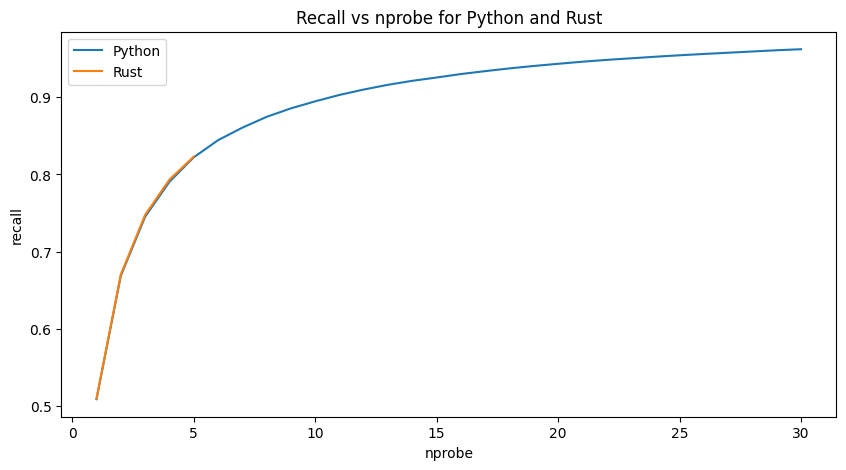

In [41]:
# Plot recall vs nprobe for python and rust
import matplotlib.pyplot as plt
import seaborn as sns

# Plot recall vs nprobe for python
plt.figure(figsize=(10, 5))

sns.lineplot(x='nprobe', y='recall', data=python_res, label='Python')
sns.lineplot(x='nprobe', y='recall', data=rust_res, label='Rust')

plt.xlabel('nprobe')
plt.ylabel('recall')
plt.title('Recall vs nprobe for Python and Rust')
plt.legend()

Text(0.5, 0, 'nprobe')

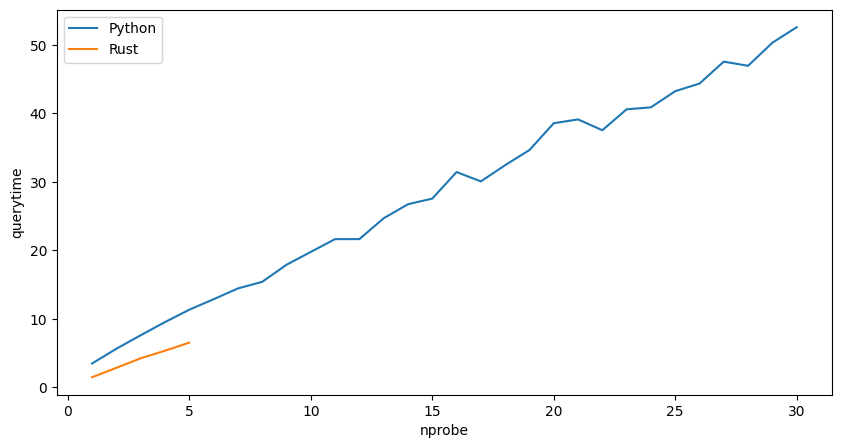

In [43]:
# Plot query time vs nprobe for python and rust
plt.figure(figsize=(10, 5))

sns.lineplot(x='nprobe', y='querytime', data=python_res, label='Python')
sns.lineplot(x='nprobe', y='querytime', data=rust_res, label='Rust')

plt.xlabel('nprobe')